<a href="https://colab.research.google.com/github/jayukarde10/AIML-Lab/blob/main/Copy_of_AI_ML_Experiment_No_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiment 1

##Simple and Multiple Linear Regression

###Objective
* Understand Simple Linear Regression
* Understand Multiple Linear Regression
* Train regression models using Scikit-learn
* Evaluate models using MAE, MSE and RMSE
* Make predictions for new data



# Introduction

Suppose a teacher wants to predict the marks of a student based on the number of hours they study.

Can a computer automatically learn this relationship?

The answer is **Yes**.

This is where **Linear Regression** comes into the picture.

Linear Regression is one of the simplest Machine Learning algorithms used to predict a continuous numerical value.

## Real-Life Applications of Linear Regression

Linear Regression is widely used in many real-world applications:

- 📚 Predicting student marks based on study hours
- 🏠 House price prediction
- 💰 Salary prediction based on years of experience
- 🛒 Sales forecasting
- 🌡️ Temperature prediction
- 🚗 Fuel consumption prediction

In this experiment, we will first predict student marks using **Simple Linear Regression** and then predict petrol consumption using **Multiple Linear Regression**.

# Simple Linear Regression

Simple Linear Regression is used when there is:

- One Input Variable (Independent Variable)
- One Output Variable (Dependent Variable)

It tries to find the **best-fit straight line** that represents the relationship between the input and output.

Mathematical Equation:

\[
y = mx + c
\]

where,

- x = Independent Variable
- y = Dependent Variable
- m = Slope of the line
- c = Intercept

In [ ]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Display plots inside notebook
%matplotlib inline

# Step 1 : Load the Dataset

The dataset contains two columns:

- Hours → Number of study hours
- Scores → Student marks

Our goal is to predict the student's marks based on the number of study hours.

In [ ]:
# Load Dataset
dataset = pd.read_csv("student_scores.csv")

dataset.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


# Step 2 : Explore the Dataset

Before building any Machine Learning model, we should understand the dataset.

We will check:

- Shape of dataset
- Column names
- Data types
- Missing values
- Statistical summary

In [ ]:
print("Shape of Dataset :", dataset.shape)
print("\n")

print(dataset.info())

Shape of Dataset : (25, 2)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes
None


In [ ]:
dataset.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [ ]:
dataset.isnull().sum()

,0
Hours,0
Scores,0


# Step 3 : Visualize the Dataset

Visualization helps us understand whether a relationship exists between the variables.

If the points approximately form a straight-line pattern, then Linear Regression is a suitable algorithm.

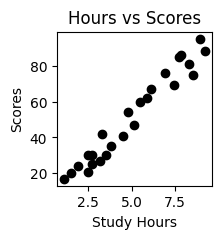

In [ ]:
from matplotlib import colors
plt.figure(figsize=(2,2))
plt.scatter(dataset['Hours'], dataset['Scores'], color="Black")
plt.xlabel("Study Hours")
plt.ylabel("Scores")
plt.title("Hours vs Scores")
plt.show()

# Step 4 : Separate Features (X) and Target (y)

Machine Learning models require the data to be separated into:

- **Features (X)** → Input variables used to make predictions.
- **Target (y)** → Output variable that we want to predict.

In this dataset:

- **Hours** is the Feature (Independent Variable)
- **Scores** is the Target (Dependent Variable)

###----------------------------
Features (X) → use double brackets [[ ]] → DataFrame (2D).
Target (y) → use single brackets [ ] → Series (1D).

In [ ]:
# Separate Feature (X) and Target (y)

X = dataset[['Hours']]
y = dataset['Scores']

print("Feature (X):")
display(X.head())

print("Target (y):")
display(y.head())

Feature (X):


,Hours
0,2.5
1,5.1
2,3.2
3,8.5
4,3.5


Target (y):


,Scores
0,21
1,47
2,27
3,75
4,30


# Step 5 : Split the Dataset

Before training a Machine Learning model, we divide the dataset into two parts.

### Training Data
Used to teach the model.

### Testing Data
Used to check how well the model performs on unseen data.

In this experiment:

- 80% data → Training
- 20% data → Testing

This helps us evaluate whether the model has actually learned the relationship instead of simply memorizing the data.

###Argument that train_test_split takes

| Argument | Purpose | Example |
|----------|---------|---------|
| `X` | Input features (independent variables) | `X` |
| `y` | Target/output (dependent variable) | `y` |
| `test_size` | Specifies the proportion or number of samples to use as the test set | `0.2` or `20` |
| `train_size` | Specifies the proportion or number of samples to use as the training set | `0.8` or `80` |
| `random_state` | Makes the train-test split reproducible by fixing the random seed | `42` |
| `shuffle` | Shuffles the data before splitting | `True` or `False` |


In [ ]:
# Split the dataset into Training and Testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42

)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (20, 1)
Testing Features  : (5, 1)
Training Target   : (20,)
Testing Target    : (5,)


In [ ]:
print("Training Data")

display(pd.concat([X_train, y_train], axis=1).head()) #pd.concat() means concatenate, i.e., join or combine pandas objects (DataFrames or Series).
#axis= 0 (rows), 1 (columns)
print("\nTesting Data")

display(pd.concat([X_test, y_test], axis=1))

Training Data


,Hours,Scores
9,2.7,25
13,3.3,42
1,5.1,47
22,3.8,35
5,1.5,20



Testing Data


,Hours,Scores
8,8.3,81
16,2.5,30
0,2.5,21
23,6.9,76
11,5.9,62


# Step 6 : Train the Linear Regression Model

Now we create a Linear Regression model and train it using the training dataset.

The **fit()** function helps the model learn the relationship between the input (Hours) and the output (Scores).

After training, the model can predict marks for new students.

### Linear Regression Workflow

| Code | Purpose |
|------|---------|
| `model = LinearRegression()` | Create an empty Linear Regression model. |
| `model.fit(X_train, y_train)` | Train (teach) the model using the training data. |
| `model.predict(X_test)` | Use the trained model to predict outputs for new/unseen data. |


In [ ]:
# Create the Linear Regression model

model = LinearRegression()

# Train the model

model.fit(X_train, y_train) # .fit do Train the model using the given data.

print("Model trained successfully!")

Model trained successfully!


# Step 7 : Display Model Parameters

After training, the model learns the equation of the best-fit line.

\[
y = mx + c
\]

where,

- **m** = Slope (Coefficient)
- **c** = Intercept

In [ ]:
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

Slope (Coefficient): 9.682078154455697
Intercept: 2.826892353899737


# Step 8 : Visualize the Best-Fit Regression Line

The blue points represent the actual observations.

The red line represents the best-fit line learned by the Linear Regression model.

The closer the points are to the line, the better the model fits the data.

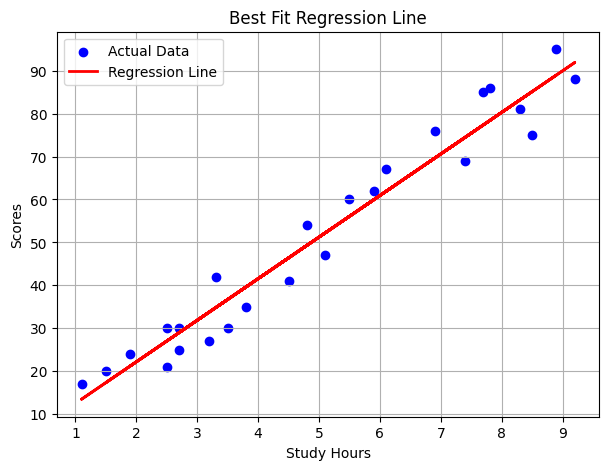

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(X, y, color='blue', label='Actual Data')

plt.plot(
    X,
    model.predict(X),
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.xlabel("Study Hours")
plt.ylabel("Scores")
plt.title("Best Fit Regression Line")

plt.legend()
plt.grid(True)

plt.show()

# Step 9 : Make Predictions on Test Data

After training the model, we use the testing dataset to check how accurately it predicts student scores.

The **predict()** function uses the learned regression equation to estimate the scores for unseen data.

In [ ]:
# Predict Scores for Test Data

y_pred = model.predict(X_test)

print("Predicted Scores:")
print(y_pred)

Predicted Scores:
[83.18814104 27.03208774 27.03208774 69.63323162 59.95115347]


# Step 10 : Compare Actual and Predicted Scores

A good Machine Learning model should produce predictions that are close to the actual values.

Let's compare the actual scores with the predicted scores.

In [ ]:
# Compare Actual vs Predicted Scores

comparison = pd.DataFrame({
    'Study Hours': X_test['Hours'].values,
    'Actual Score': y_test.values,
    'Predicted Score': y_pred.round(2)
})

comparison = comparison.sort_values(by='Study Hours').reset_index(drop=True)

comparison

,Study Hours,Actual Score,Predicted Score
0,2.5,30,27.032088
1,2.5,21,27.032088
2,5.9,62,59.951153
3,6.9,76,69.633232
4,8.3,81,83.188141


# Step 11 : Predict Scores for New Students

One of the main purposes of Machine Learning is to make predictions for new data that the model has never seen before.

Let's predict the scores of students studying for different numbers of hours.

In [ ]:
# Predict Scores for New Students

new_hours = pd.DataFrame({
    'Hours': [5, 7.5, 9, 10, 12]
})

predicted_scores = model.predict(new_hours)

result = new_hours.copy()
result['Predicted Score'] = predicted_scores.round(2)

result

,Hours,Predicted Score
0,5.0,51.24
1,7.5,75.44
2,9.0,89.97
3,10.0,99.65
4,12.0,119.01


In [ ]:
# Activity: Change these values and observe the predicted scores

hours = pd.DataFrame({
    'Hours': [6, 8, 11]
})

predictions = model.predict(hours)

pd.DataFrame({
    "Study Hours": hours['Hours'],
    "Predicted Score": predictions.round(2)
})

,Study Hours,Predicted Score
0,6,60.92
1,8,80.28
2,11,109.33


# Step 12 : Evaluate Model Performance

To determine how well our model performs, we calculate different error metrics.

The three commonly used regression evaluation metrics are:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

Lower values indicate better model performance.

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 3.92
Mean Squared Error (MSE): 18.94
Root Mean Squared Error (RMSE): 4.35


# Step 13 : Coefficient of Determination (R² Score)

In addition to measuring prediction error, we also want to know **how well the regression model explains the variation in the target variable**.

The **R² Score (Coefficient of Determination)** measures the proportion of variance in the target variable that is explained by the model.

### Interpretation

- **R² = 1.0** → Perfect prediction
- **R² = 0.0** → Model performs no better than predicting the average value
- **Higher R² values indicate a better model**

Unlike MAE, MSE, and RMSE, the R² Score measures the **goodness of fit** rather than the prediction error.

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print(f"R² Score : {r2:.4f}")

R² Score : 0.9678


# Interpretation of R² Score

The R² Score indicates how much of the variation in the target variable is explained by the regression model.

| R² Score | Interpretation |
|----------|----------------|
| 1.00 | Perfect prediction |
| 0.90 – 0.99 | Excellent model |
| 0.70 – 0.89 | Good model |
| 0.50 – 0.69 | Moderate model |
| Below 0.50 | Weak model |

A higher R² Score generally indicates a better-fitting regression model.

# Understanding Performance Metrics

### Mean Absolute Error (MAE)

- Average of the absolute differences between actual and predicted values.
- Easy to understand because it is in the same unit as the target variable.

### Mean Squared Error (MSE)

- Average of the squared prediction errors.
- Gives higher importance to larger errors.

### Root Mean Squared Error (RMSE)

- Square root of MSE.
- Represents the average prediction error in the original unit.
- Easier to interpret than MSE.

**For all these metrics, a lower value indicates a better-performing model.**

In [ ]:
evaluation = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Value": [
        round(mae,2),
        round(mse,2),
        round(rmse,2),
        round(r2,4)
    ]
})

evaluation

,Metric,Value
0,MAE,3.9200
1,MSE,18.9400
2,RMSE,4.3500
3,R² Score,0.9678


# Step 13 : Conclusion

In this experiment, we successfully:

✅ Loaded and explored the dataset.

✅ Built a Simple Linear Regression model.

✅ Learned the best-fit regression equation.

✅ Predicted student scores.

✅ Evaluated the model using MAE, MSE, and RMSE.

Simple Linear Regression is suitable when there is **one independent variable** and **one dependent variable**.

# Limitation of Simple Linear Regression

In this experiment, we predicted student scores using only **one feature (Study Hours).**

But in real life, marks may also depend on many other factors such as:

- Attendance
- Sleep Hours
- Previous Performance
- Assignment Scores
- Class Participation

When **multiple input features** affect the output, we use **Multiple Linear Regression**.

In the next section, we will learn how to build a Multiple Linear Regression model using four input variables to predict petrol consumption.

# Multiple Linear Regression

In Simple Linear Regression, we used only **one independent variable** to predict the output.

However, many real-world problems depend on **multiple input variables**.

For example:

### Predicting Petrol Consumption

Petrol consumption may depend on:

- Petrol Tax
- Average Income
- Paved Highways
- Population Driving License

Since multiple factors influence the output, **Multiple Linear Regression** is a more suitable algorithm.

## Mathematical Equation

Simple Linear Regression:

\[
y = mx + c
\]

Multiple Linear Regression:

\[
y = b_0 + b_1x_1 + b_2x_2 + b_3x_3 + b_4x_4
\]

where,

- \(x_1\) = Petrol Tax
- \(x_2\) = Average Income
- \(x_3\) = Paved Highways
- \(x_4\) = Population Driving License

Each feature contributes to predicting Petrol Consumption.

# Step 1 : Load the Dataset

The dataset contains information related to petrol consumption in different regions.

Our objective is to predict **Petrol Consumption** using four independent variables.

In [ ]:
dataset = pd.read_csv("petrol_consumption.csv")

dataset.head()

FileNotFoundError: [Errno 2] No such file or directory: 'petrol_consumption.csv'

# Step 2 : Explore the Dataset

Before training the model, let's understand the dataset.

We will check:

- Number of rows and columns
- Data types
- Missing values
- Statistical summary

In [ ]:
print("Shape :", dataset.shape)
print()

dataset.info()

In [ ]:
dataset.describe()

In [ ]:
dataset.isnull().sum()

# Step 3 : Understanding the Relationship Between Features

Before building a Machine Learning model, it is useful to understand how different features are related.

A **Correlation Matrix** helps us identify positive and negative relationships between variables.

In [ ]:
dataset.corr()

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    dataset.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# Step 4 : Separate Features and Target

Machine Learning requires the input features and output variable to be separated.

Features (X):

- Petrol Tax
- Average Income
- Paved Highways
- Population Driving License

Target (y):

- Petrol Consumption

In [ ]:
X = dataset.drop("Petrol_Consumption", axis=1)

y = dataset["Petrol_Consumption"]

print("Features")

display(X.head())

print("Target")

display(y.head())

# Step 5 : Split the Dataset

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

The training data is used to teach the model, while the testing data is used to evaluate its performance on unseen data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

# Step 6 : Train the Multiple Linear Regression Model

The model learns the relationship between all four input variables and Petrol Consumption.

After training, it can predict petrol consumption for new data.

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

# Step 7 : Model Coefficients

Unlike Simple Linear Regression, Multiple Linear Regression has one coefficient for each feature.

These coefficients indicate how much each feature influences the prediction while keeping the other features constant.

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

# Step 8 : Make Predictions on Test Data

After training the model, we use the testing dataset to predict petrol consumption for unseen data.

The **predict()** function applies the learned relationship between the input features and the target variable.

In [ ]:
# Predict Petrol Consumption for Test Data

y_pred = model.predict(X_test)

print("Predicted Petrol Consumption:")
print(y_pred)

# Step 9 : Compare Actual and Predicted Values

A good Machine Learning model should produce predictions that are close to the actual values.

Let's compare the actual petrol consumption with the predicted values.

In [ ]:
comparison = X_test.copy()

comparison["Actual Petrol Consumption"] = y_test.values
comparison["Predicted Petrol Consumption"] = np.round(y_pred, 2)

comparison.reset_index(drop=True)

# Step 10 : Predict Petrol Consumption for a New Region

Now let's use our trained model to predict petrol consumption for a completely new region.

Suppose the region has:

- Petrol Tax = 7.0
- Average Income = 5000
- Paved Highways = 6000
- Population Driving License = 7000

The model will estimate the petrol consumption based on these values.

In [ ]:
# Predict Petrol Consumption for New Data
# ⚠ Important: Use the exact column names from your dataset.
# If the dataset uses different capitalization or spacing, update the column names accordingly.

new_region = pd.DataFrame({
    "Petrol_tax": [7.0],
    "Average_income": [5000],
    "Paved_Highways": [6000],
    "Population_Driver_licence(%)": [7000]
})

prediction = model.predict(new_region)

print(f"Predicted Petrol Consumption : {prediction[0]:.2f}")

# Step 11 : Evaluate Model Performance

Regression models are evaluated using error metrics.

The most commonly used metrics are:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

Lower values indicate better prediction performance.

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

In [ ]:
evaluation = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE"],
    "Value": [mae, mse, rmse]
})

evaluation

# Interpretation of Evaluation Metrics

### Mean Absolute Error (MAE)

- Measures the average absolute difference between actual and predicted values.
- Easy to understand because it is in the original unit.

### Mean Squared Error (MSE)

- Squares the prediction errors before averaging.
- Penalizes larger errors more heavily.

### Root Mean Squared Error (RMSE)

- Square root of MSE.
- Represents the average prediction error in the original unit.

**For all three metrics, lower values indicate better model performance.**

# Step 12 : Why is the RMSE Higher?

The RMSE obtained is:

- MAE = 53.47
- MSE = 4083.26
- RMSE = 63.90

A higher RMSE does **not necessarily mean that the model is bad**.

To understand the reason, we need to analyze the dataset and the predictions.

In [ ]:
# Compare Actual and Predicted Values

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": np.round(y_pred,2)
})

comparison["Error"] = comparison["Actual"] - comparison["Predicted"]
comparison["Absolute Error"] = abs(comparison["Error"])

comparison.sort_values(by="Absolute Error", ascending=False)

In [ ]:
# Visualize Actual vs Predicted

plt.figure(figsize=(8,5))

plt.plot(y_test.values,
         marker='o',
         label='Actual')

plt.plot(y_pred,
         marker='s',
         label='Predicted')

plt.title("Actual vs Predicted Petrol Consumption")

plt.xlabel("Test Samples")
plt.ylabel("Petrol Consumption")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Distribution of Prediction Errors

errors = y_test - y_pred

plt.figure(figsize=(7,5))

plt.hist(errors,
         bins=8,
         edgecolor='black')

plt.title("Distribution of Prediction Errors")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

## Why is RMSE Higher?

There are several possible reasons:

### 1. Small Dataset

The Petrol Consumption dataset contains only **48 observations**.

A small dataset makes it difficult for the model to learn all relationships accurately.

---

### 2. Real-World Data is Complex

Petrol consumption depends on many factors beyond the four features used in this dataset, such as:

- Fuel prices
- Public transportation
- Vehicle ownership
- Economic conditions
- Government policies

Since these variables are not included, prediction errors increase.

---

### 3. Presence of Outliers

Some regions may have petrol consumption values that are significantly different from the others.

These unusual observations increase the squared error, resulting in a higher RMSE.

---

### 4. Linear Relationship Assumption

Linear Regression assumes a linear relationship between the features and the target variable.

If the actual relationship is nonlinear, prediction accuracy decreases.

---

### 5. RMSE Penalizes Large Errors

RMSE squares each prediction error before averaging.

Therefore, even a few large prediction errors can significantly increase the RMSE value.

In [ ]:
# Maximum Prediction Error

print("Maximum Absolute Error:",
      np.max(abs(y_test - y_pred)))

print("Average Absolute Error:",
      np.mean(abs(y_test - y_pred)))

We often think that adding more input features automatically makes a model better. That's not always true. A model's performance depends on the quality and relevance of the data, the size of the dataset, and whether the relationship between inputs and outputs is actually linear. In this experiment, the RMSE is relatively high because petrol consumption is influenced by many real-world factors that are not included in our dataset. This demonstrates an important lesson in machine learning: better features and better data are often more valuable than simply having more features

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print(f"R² Score : {r2:.3f}")

For the Petrol Consumption dataset, we are getting an R² value around 0.4, indicating that the model explains only part of the variation in petrol consumption. This is expected because the dataset is small and petrol consumption is influenced by many factors beyond the four features provided.

# Simple Linear Regression vs Multiple Linear Regression

| Simple Linear Regression | Multiple Linear Regression |
|--------------------------|----------------------------|
| Uses one independent variable | Uses multiple independent variables |
| Predicts one dependent variable | Predicts one dependent variable |
| Equation: y = mx + c | Equation: y = b₀ + b₁x₁ + b₂x₂ + ... |
| Easy to visualize using a straight line | Difficult to visualize beyond three dimensions |
| Simpler model | More suitable for real-world problems with multiple influencing factors |

# Conclusion

In this experiment, we successfully:

✅ Understood Simple Linear Regression.

✅ Built a model to predict student scores.

✅ Learned the concept of the best-fit regression line.

✅ Evaluated the model using MAE, MSE, and RMSE.

✅ Understood Multiple Linear Regression.

✅ Built a model using multiple input features.

✅ Predicted petrol consumption for unseen data.

Regression algorithms are widely used in machine learning for predicting continuous numerical values in various real-world applications such as education, finance, healthcare, sales forecasting, and price prediction.

# Mini Activity

Modify the input values below and observe how the predicted petrol consumption changes.

Try different combinations of:

- Petrol Tax
- Average Income
- Paved Highways
- Population Driving License

Observe which feature appears to have the greatest impact on the prediction.

In [ ]:
# Activity: Change these values and observe the prediction

new_region = pd.DataFrame({
    "Petrol_tax": [6.5],
    "Average_income": [4500],
    "Paved_Highways": [5200],
    "Population_Driver_licence(%)": [6500]
})

prediction = model.predict(new_region)

print(f"Predicted Petrol Consumption: {prediction[0]:.2f}")